In [ ]:
# Online Shoppers Purchasing Intention – EDA

# This notebook performs exploratory data analysis (EDA) for the UCI Online Shoppers Purchasing Intention dataset.  
# Goal: understand the data structure, quality, and key patterns related to purchase intention (`Revenue`).

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Make plots look nicer
plt.style.use("default")
sns.set(style="whitegrid")

# Show more columns when printing DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [4]:
data_path = "../data/online_shoppers_intention.csv"  # adjust if needed

In [5]:
df = pd.read_csv(data_path)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
print("Shape (rows, columns):", df.shape)
print("\nData types:")
print(df.dtypes)

# print("\nFirst 5 rows:")
# display(df.head())


Shape (rows, columns): (12330, 18)

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [7]:
# Count missing values in each column
missing_counts = df.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_counts)


Missing values per column:
Administrative             0
Administrative_Duration    0
Weekend                    0
VisitorType                0
TrafficType                0
Region                     0
Browser                    0
OperatingSystems           0
Month                      0
SpecialDay                 0
PageValues                 0
ExitRates                  0
BounceRates                0
ProductRelated_Duration    0
ProductRelated             0
Informational_Duration     0
Informational              0
Revenue                    0
dtype: int64


In [8]:
# Basic numeric summary
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumeric summary:")
display(df[numeric_cols].describe().T)


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [9]:

# Categorical summary
cat_cols = df.select_dtypes(include=["object", "bool"]).columns
print("\nCategorical columns:", list(cat_cols))
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))

#The above 3 cells this gives a quick health check of the dataset (perfect to mention in your progress report).


Categorical columns: ['Month', 'VisitorType', 'Weekend', 'Revenue']

Value counts for Month:
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

Value counts for VisitorType:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

Value counts for Weekend:
Weekend
False    9462
True     2868
Name: count, dtype: int64

Value counts for Revenue:
Revenue
False    10422
True      1908
Name: count, dtype: int64


# EDA

In [11]:
# Ensure Revenue is boolean or 0/1
print("Revenue unique values:", df["Revenue"].unique())

target_counts = df["Revenue"].value_counts()
target_ratio = df["Revenue"].value_counts(normalize=True) * 100

print("\nRevenue counts:")
print(target_counts)
print("\nRevenue ratio (%):")
print(target_ratio)

Revenue unique values: [False  True]

Revenue counts:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Revenue ratio (%):
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


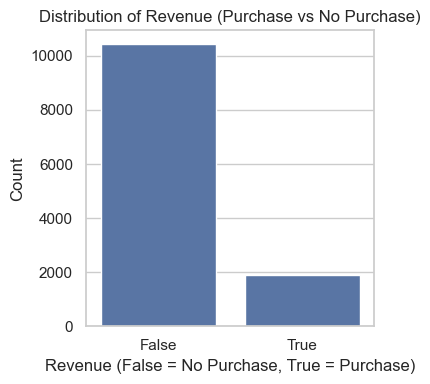

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Revenue (Purchase vs No Purchase)")
plt.xlabel("Revenue (False = No Purchase, True = Purchase)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# This gives you:

# Class balance (important for mentioning class imbalance later)

# Nice plot to reuse

### 3.2. Numeric Features – Univariate EDA

In [14]:
# Histograms for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

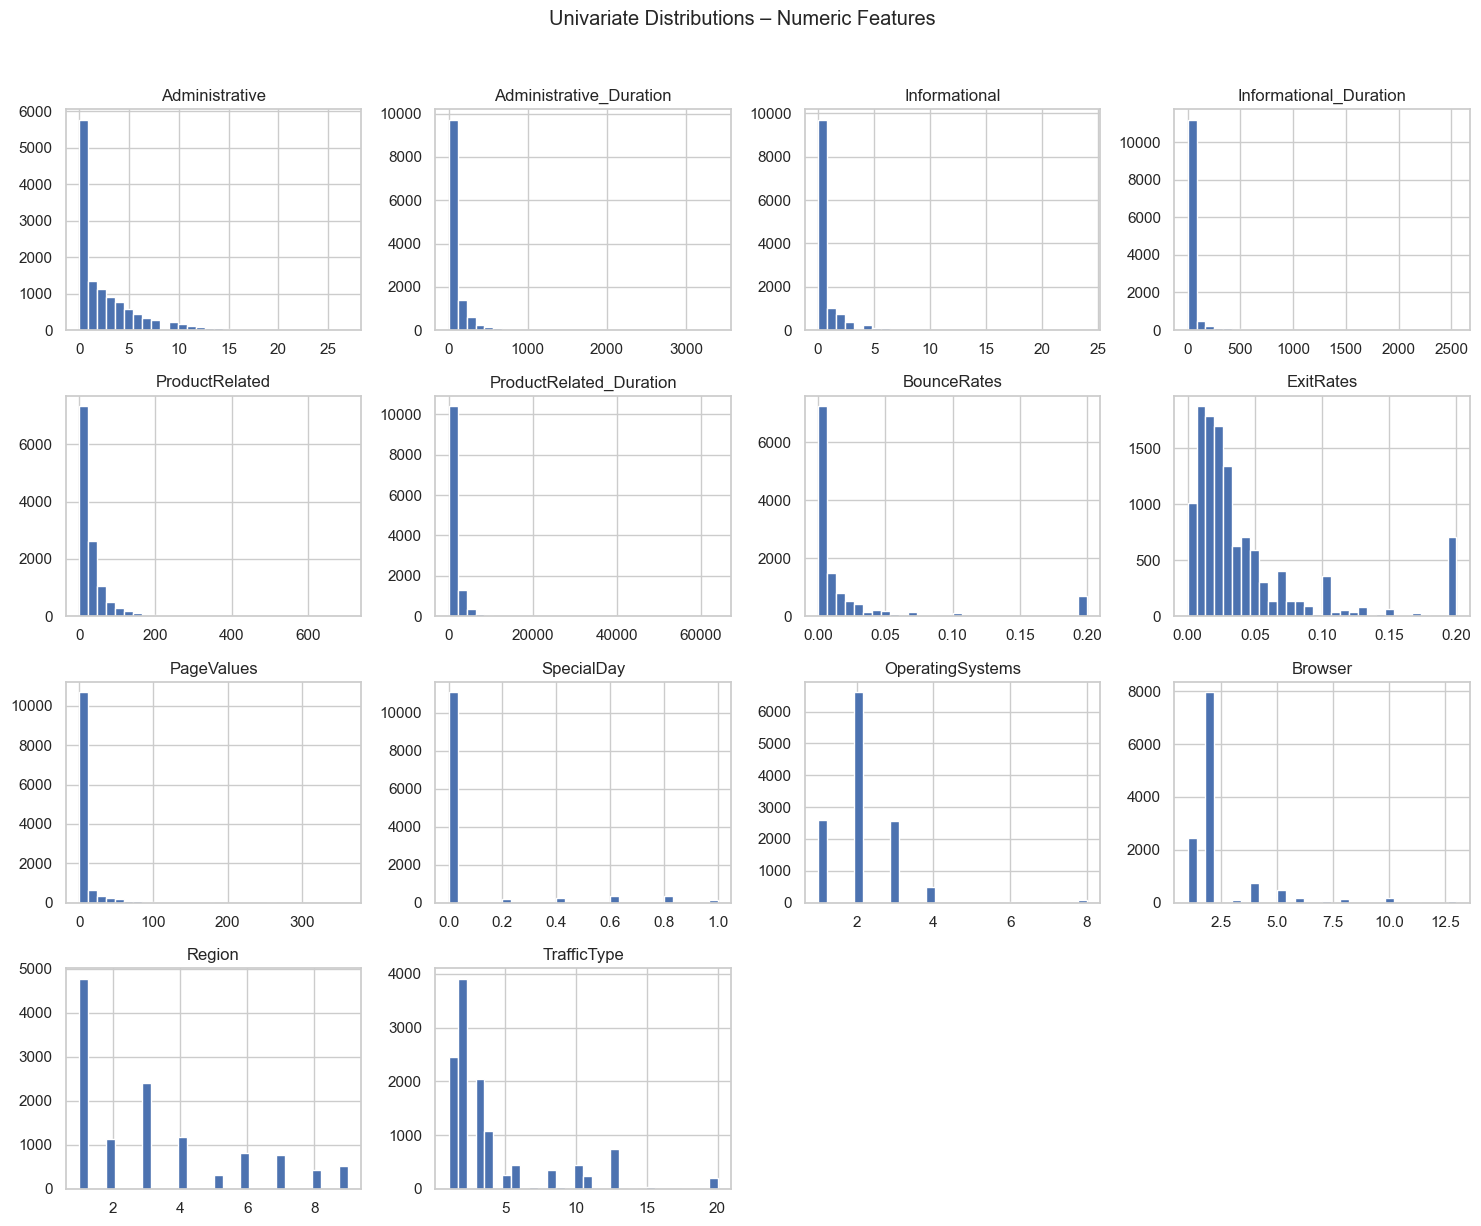

In [15]:
# Plot histograms
df[numeric_cols].hist(bins=30, figsize=(15, 12), layout=(4, 4))
plt.suptitle("Univariate Distributions – Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# You can mention:

# Which variables are skewed

# Which have a lot of zeros (e.g., durations, PageValues, SpecialDay)

In [16]:
# Numeric vs Revenue (Bivariate)
# We want to see how each numeric feature behaves for buyers vs non-buyers.

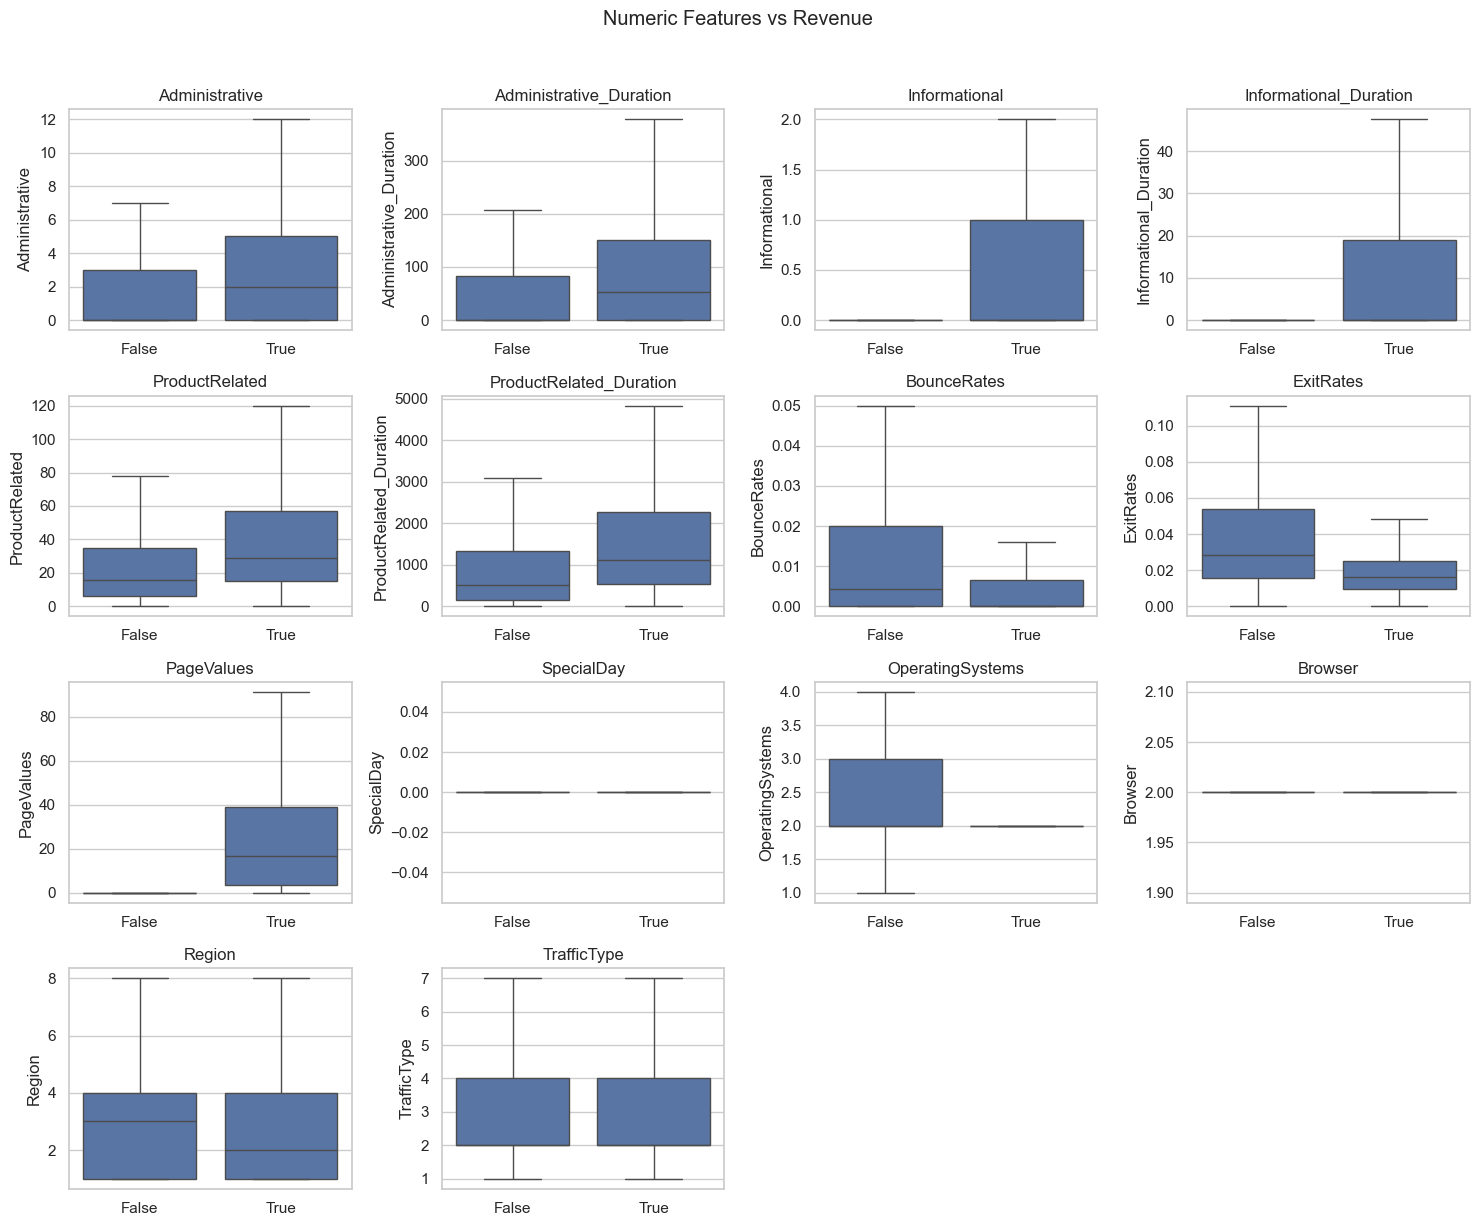

In [17]:
# Boxplots by Revenue
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x="Revenue", y=col, data=df, showfliers=False)
    plt.title(col)
    plt.xlabel("")
plt.suptitle("Numeric Features vs Revenue", y=1.02)
plt.tight_layout()
plt.show()

# This helps answer:

# Do buyers have higher PageValues?

# Do buyers spend more time on ProductRelated pages?

# Etc.

# Great material for “findings” in the report.

In [18]:
# Categorical Features – Univariate & vs Revenue
# We’ll explore Month, VisitorType, Weekend, Region, etc.

In [19]:
# Bar plots for categorical features
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()

cat_cols = [c for c in cat_cols if c != "Revenue"]
cat_cols

['Month', 'VisitorType', 'Weekend']

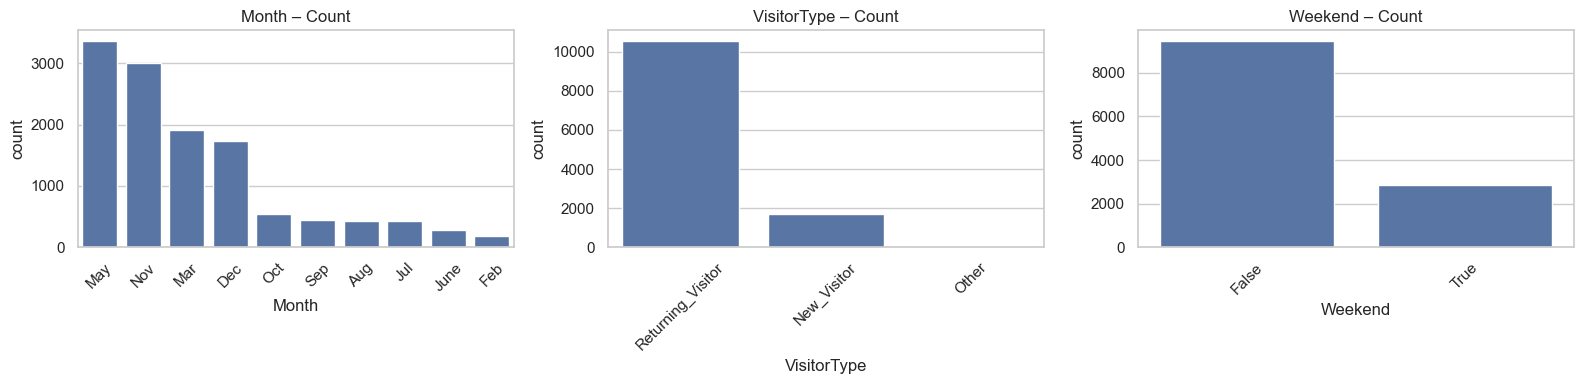

In [20]:
n_cat = len(cat_cols)
plt.figure(figsize=(16, 4 * ((n_cat + 2)//3)))

for i, col in enumerate(cat_cols, 1):
    plt.subplot((n_cat + 2)//3, 3, i)
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} – Count")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# Categorical vs Revenue (purchase rate by category)
# This is very strong for insights.


Purchase rate by Month


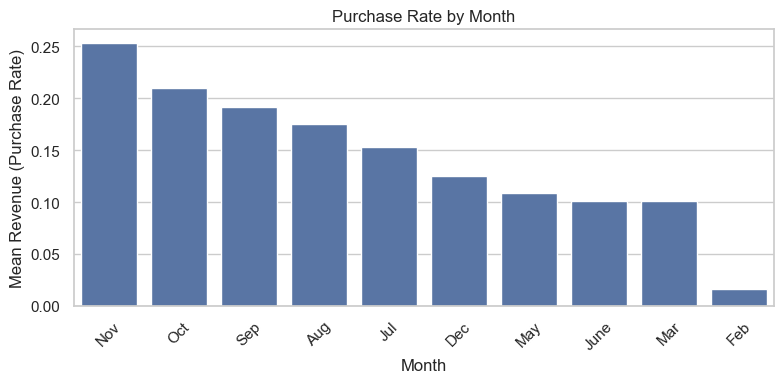

,Month,Revenue
0,Nov,0.253502
1,Oct,0.209472
2,Sep,0.191964
3,Aug,0.175520
4,Jul,0.152778
5,Dec,0.125072
6,May,0.108502
7,June,0.100694
8,Mar,0.100682
9,Feb,0.016304



Purchase rate by VisitorType


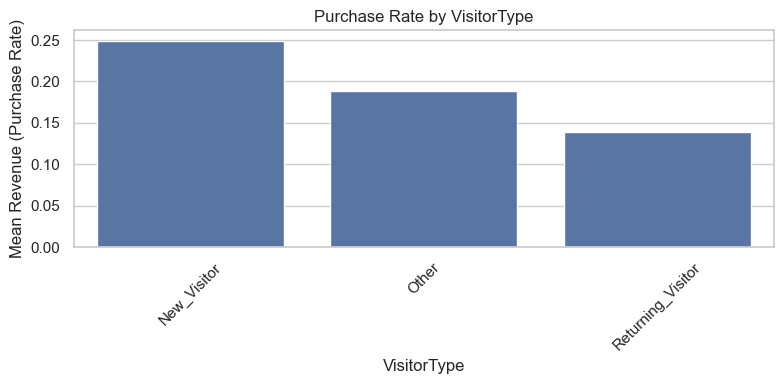

,VisitorType,Revenue
0,New_Visitor,0.249115
1,Other,0.188235
2,Returning_Visitor,0.139323



Purchase rate by Weekend


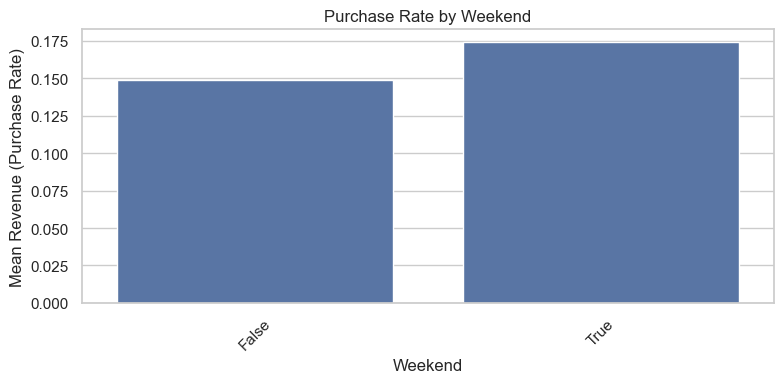

,Weekend,Revenue
0,True,0.173989
1,False,0.148911


In [22]:
def plot_purchase_rate_by_category(col):
    temp = (
        df.groupby(col)["Revenue"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y="Revenue", data=temp)
    plt.title(f"Purchase Rate by {col}")
    plt.ylabel("Mean Revenue (Purchase Rate)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    display(temp)

for col in cat_cols:
    print("\n" + "="*60)
    print(f"Purchase rate by {col}")
    plot_purchase_rate_by_category(col)


# From this, you’ll be able to say things like:

# Returning visitors have higher purchase rates than new visitors.

# Certain months (e.g., Nov/Dec) have higher purchase probability.

# Weekend vs weekday behavior.

In [23]:
# Correlation Analysis
# Now we look for relationships between numeric features.

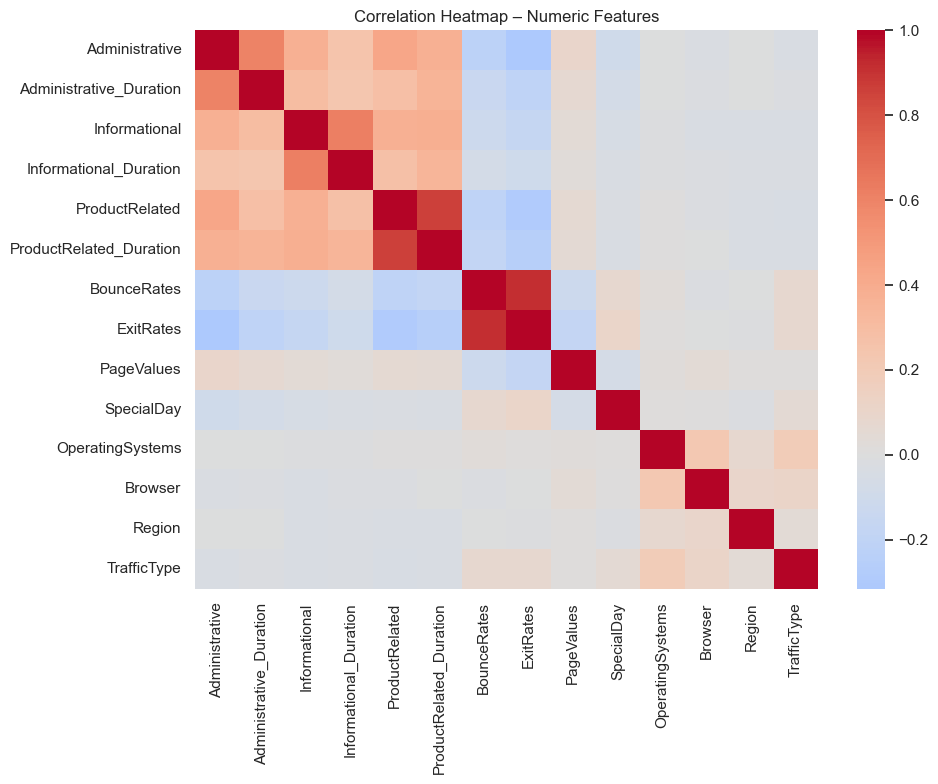

In [24]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Numeric Features")
plt.tight_layout()
plt.show()

# Strong relationships (if any) between PageValues and ProductRelated_Duration, etc.

# Multicollinearity (just mention if some features are highly correlated).

# PREPROCESSING PIPELINE

#### Cell 1 — Identify columns and split data

In [27]:
# Cell 1 — Identify columns and split data

from sklearn.model_selection import train_test_split

# Target
y = df["Revenue"].astype(int)

# Features
X = df.drop(columns=["Revenue"])

# Identify column types
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','bool']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical columns: ['Month', 'VisitorType', 'Weekend']
Train size: (9864, 17)
Test size: (2466, 17)


In [28]:
# Cell 2 — Preprocessing pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for numeric columns: Standard scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown="ignore"))
])

# Combine both in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay', 'OperatingSystems', 'Browser',
                                  'Region', 'TrafficType']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Month', 'VisitorType', 'Weekend'])])

# STEP 5 — BASELINE MODEL (LOGISTIC REGRESSION)

In [30]:
# Cell 3 — Train Logistic Regression Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_reg_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'VisitorType',
                                                   'Weekend'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [31]:
# Cell 4 — Evaluate the Baseline Model
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Predictions
y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2084
           1       0.51      0.75      0.61       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.76      2466
weighted avg       0.88      0.85      0.86      2466

ROC-AUC: 0.8961999175970496


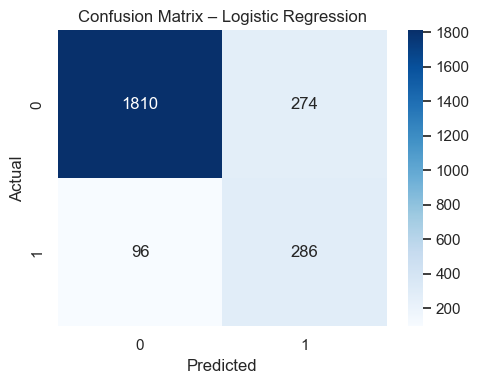

In [32]:
# Cell 5 — Confusion Matrix + ROC Curve
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


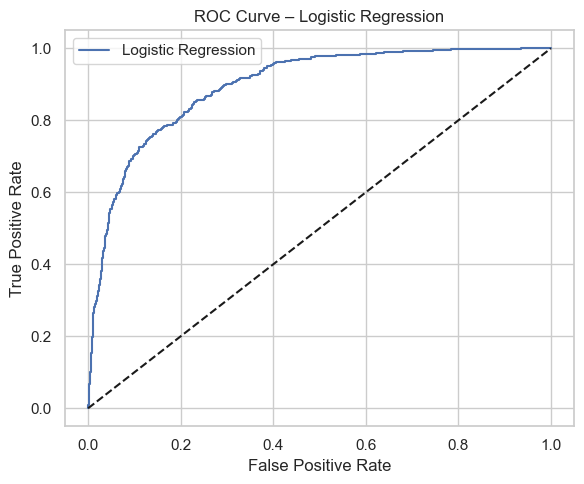

In [33]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


# Random Forest Classifier

In [35]:
# Import and Build the RF Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])


In [36]:
# Train Random Forest
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'VisitorType',
                                                   'Weekend'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [37]:
# Evaluate RF
from sklearn.metrics import classification_report, roc_auc_score

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n===== RANDOM FOREST RESULTS =====")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))



===== RANDOM FOREST RESULTS =====
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.75      0.52      0.61       382

    accuracy                           0.90      2466
   macro avg       0.83      0.74      0.78      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.9224463878365206


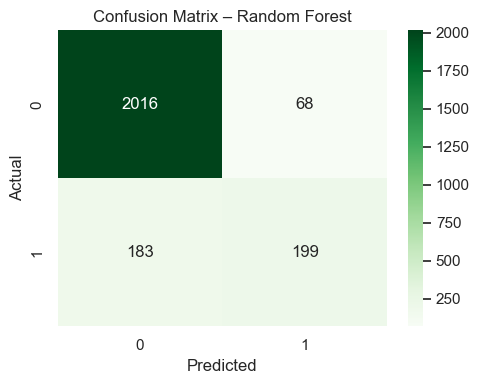

In [38]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


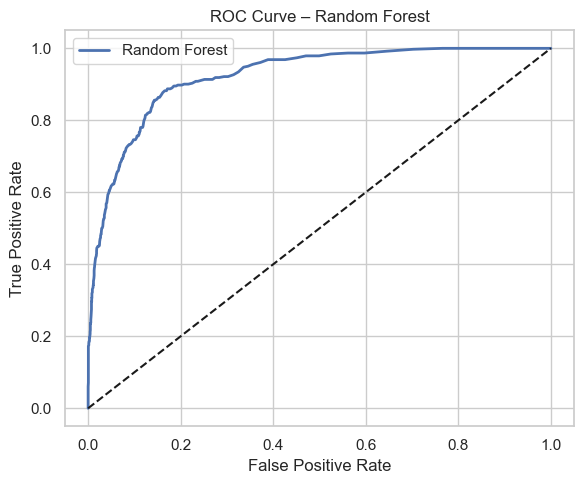

In [39]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Random Forest', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve – Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# Feature Importance (before SHAP)

# This is NOT the same as SHAP — but still useful as early insight.

# We need to extract the transformed feature names:




# Extract feature names after OHE transformation
ohe = rf_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

num_feature_names = numeric_cols
all_features = list(num_feature_names) + list(cat_feature_names)


In [41]:
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

feat_importances = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_importances.head(20)


,feature,importance
8,PageValues,0.383196
7,ExitRates,0.095836
5,ProductRelated_Duration,0.084139
4,ProductRelated,0.067218
6,BounceRates,0.056005
1,Administrative_Duration,0.049750
0,Administrative,0.037694
13,TrafficType,0.026997
21,Month_Nov,0.026677
12,Region,0.026154


/var/folders/5z/d2ttcdv15d38751y42yy_yfc0000gn/T/ipykernel_5393/1170459548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


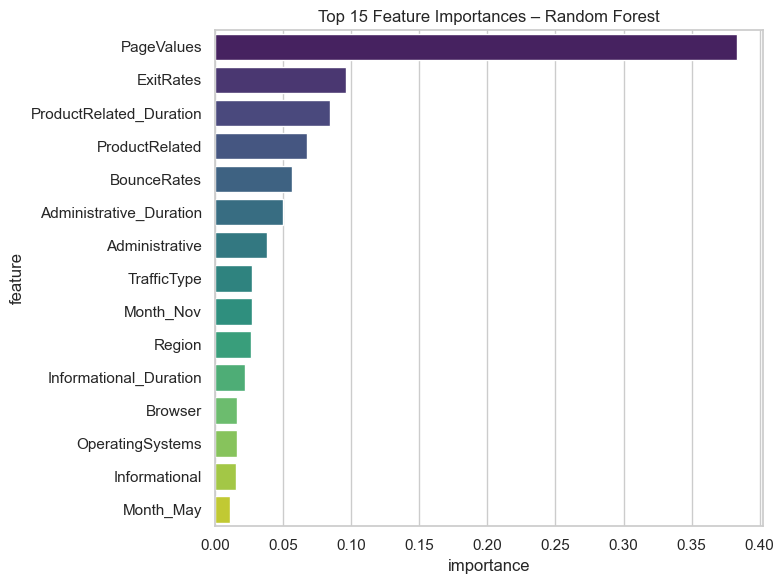

In [42]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='importance', y='feature',
    data=feat_importances.head(15),
    palette='viridis'
)
plt.title("Top 15 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()


# xgboost

In [44]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [46]:
# Compute class imbalance ratio (for scale_pos_weight)
# Make sure y_train is 0/1 integers
y_train.value_counts()


Revenue
0    8338
1    1526
Name: count, dtype: int64

In [47]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count
scale_pos_weight

5.463958060288335

In [48]:
# 2. Build the XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',       # avoids deprecated warning
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])


In [49]:
# 3. Train the XGBoost Model
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 (...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [50]:
# 4. Evaluate XGBoost Performance
y_pred_xgb  = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("===== XGBOOST CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_xgb))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("XGBoost ROC-AUC:", auc_xgb)


===== XGBOOST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2084
           1       0.59      0.74      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.88      2466

XGBoost ROC-AUC: 0.9235599581955763


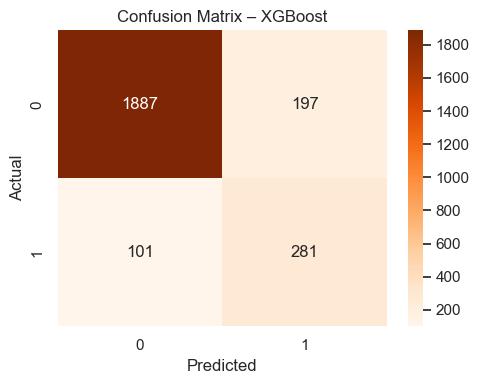

In [51]:
# 5. Confusion Matrix & ROC Curve
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix – XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


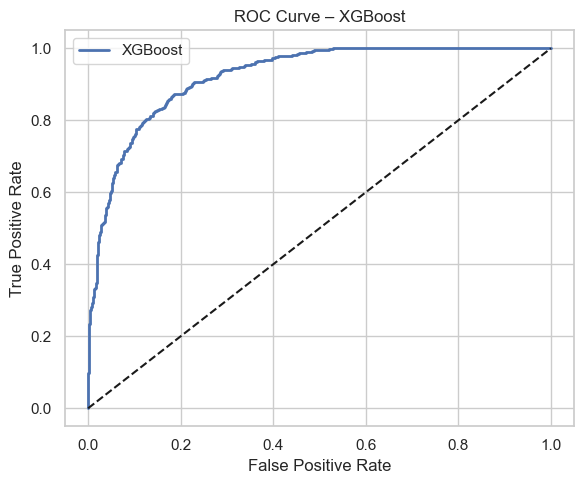

In [52]:
# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


In [53]:
# 6. Feature Importance (XGBoost built-in)
# After fitting xgb_pipeline
ohe = xgb_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

num_feature_names = numeric_cols
all_features = list(num_feature_names) + list(cat_feature_names)
len(all_features)


29

In [54]:
xgb_model = xgb_pipeline.named_steps['model']
importances = xgb_model.feature_importances_

feat_importances_xgb = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_importances_xgb.head(20)


,feature,importance
8,PageValues,0.215208
20,Month_May,0.100443
21,Month_Nov,0.097617
19,Month_Mar,0.094146
23,Month_Sep,0.044236
26,VisitorType_Returning_Visitor,0.025322
7,ExitRates,0.024051
17,Month_Jul,0.023259
24,VisitorType_New_Visitor,0.023126
5,ProductRelated_Duration,0.021950


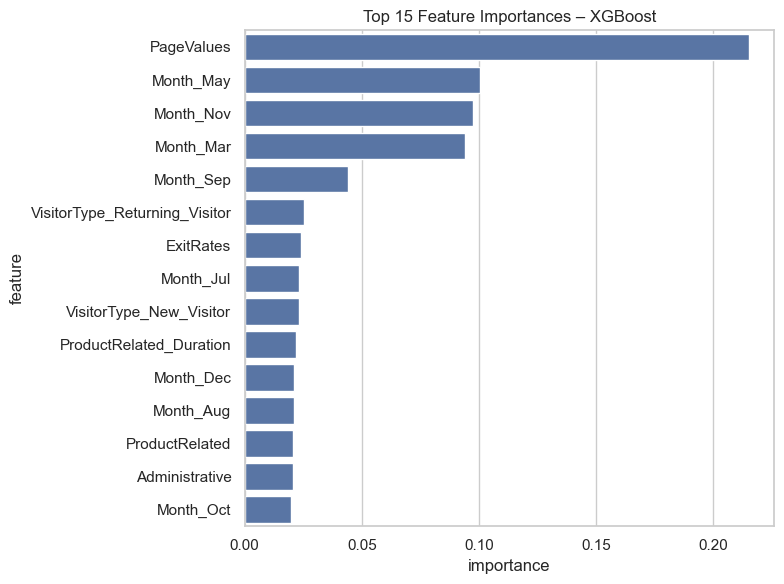

In [55]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='importance',
    y='feature',
    data=feat_importances_xgb.head(15)
)
plt.title("Top 15 Feature Importances – XGBoost")
plt.tight_layout()
plt.show()


In [56]:
# Store Metrics for Comparison Table
results = []

# Example: append for existing models first, if you still have their metrics
# results.append({"model": "Logistic Regression", "roc_auc": auc_lr, "accuracy": acc_lr, ...})
# results.append({"model": "Random Forest", "roc_auc": auc_rf, "accuracy": acc_rf, ...})

from sklearn.metrics import accuracy_score

acc_xgb = accuracy_score(y_test, y_pred_xgb)

results.append({
    "model": "XGBoost",
    "accuracy": acc_xgb,
    "roc_auc": auc_xgb
})

pd.DataFrame(results)


,model,accuracy,roc_auc
0,XGBoost,0.879157,0.92356


# LightGBM Model

In [58]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [59]:
from lightgbm import LGBMClassifier


In [60]:
# Build the LightGBM Pipeline
lgb_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


In [61]:
# Train LightGBM
lgb_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1526, number of negative: 8338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1911
[LightGBM] [Info] Number of data points in the train set: 9864, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'VisitorType',
                                                   'Weekend'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
                                learning_rate=0.03, n_estimators=500, n_jobs=-1,
                                random_state=42, subsample=0.9))])

In [62]:
# Evaluate LightGBM
y_pred_lgb  = lgb_pipeline.predict(X_test)
y_proba_lgb = lgb_pipeline.predict_proba(X_test)[:, 1]

print("===== LIGHTGBM RESULTS =====")
print(classification_report(y_test, y_pred_lgb))

auc_lgb = roc_auc_score(y_test, y_proba_lgb)
print("LightGBM ROC-AUC:", auc_lgb)


===== LIGHTGBM RESULTS =====
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2084
           1       0.58      0.74      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.88      2466

LightGBM ROC-AUC: 0.9247068163318628


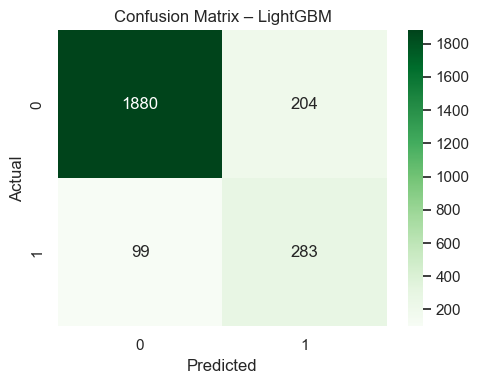

In [63]:
# Confusion Matrix & ROC Curve
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lgb),
            annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


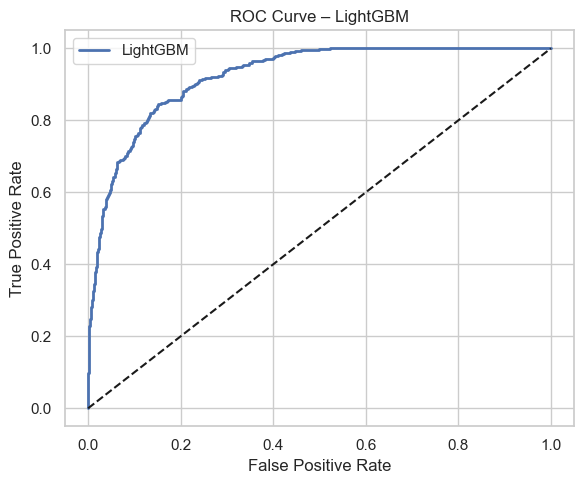

In [64]:
# ROC curve
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_lgb, tpr_lgb, label='LightGBM', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – LightGBM")
plt.legend()
plt.tight_layout()
plt.show()


In [65]:
# 5 LightGBM Feature Importance
lgb_model = lgb_pipeline.named_steps['model']
importances_lgb = lgb_model.feature_importances_


In [66]:
ohe = lgb_pipeline.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

num_feature_names = numeric_cols
all_features = list(num_feature_names) + list(cat_feature_names)


In [67]:
feat_lgb = pd.DataFrame({
    'feature': all_features,
    'importance': importances_lgb
}).sort_values(by='importance', ascending=False)

feat_lgb.head(20)


,feature,importance
7,ExitRates,1981
5,ProductRelated_Duration,1861
4,ProductRelated,1735
1,Administrative_Duration,1506
8,PageValues,1294
6,BounceRates,1182
0,Administrative,775
13,TrafficType,774
3,Informational_Duration,767
12,Region,557


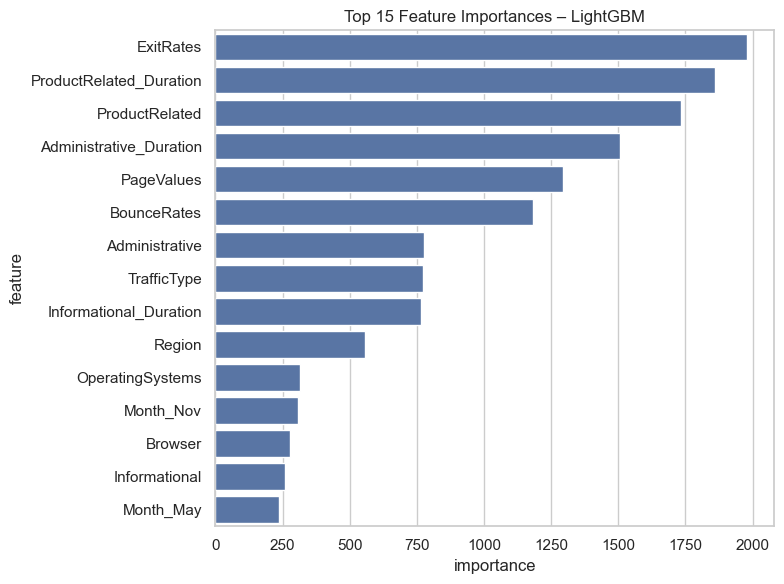

In [68]:
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature',
            data=feat_lgb.head(15))
plt.title("Top 15 Feature Importances – LightGBM")
plt.tight_layout()
plt.show()


In [69]:
# Update Your Model Comparison Tableresults.append({
results.append({
    "model": "LightGBM",
    "accuracy": accuracy_score(y_test, y_pred_lgb),
    "roc_auc": auc_lgb
})

pd.DataFrame(results)



,model,accuracy,roc_auc
0,XGBoost,0.879157,0.923560
1,LightGBM,0.877129,0.924707


# Compare All Models in a Results Table

In [71]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)


In [72]:
def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }


In [73]:
# Generate predictions for Logistic Regression
y_pred_lr  = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]


In [74]:
# Evaluate each model
results = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_proba_lr),
    "Random Forest": evaluate_model(y_test, y_pred_rf, y_proba_rf),
    "XGBoost": evaluate_model(y_test, y_pred_xgb, y_proba_xgb),
    "LightGBM": evaluate_model(y_test, y_pred_lgb, y_proba_lgb)
}


In [75]:
# Convert to pandas DataFrame
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.849959,0.510714,0.748691,0.607219,0.896200
Random Forest,0.898216,0.745318,0.520942,0.613251,0.922446
XGBoost,0.879157,0.587866,0.735602,0.653488,0.923560
LightGBM,0.877129,0.581109,0.740838,0.651323,0.924707


In [76]:
# Sort by ROC-AUC (best model on top)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
LightGBM,0.877129,0.581109,0.740838,0.651323,0.924707
XGBoost,0.879157,0.587866,0.735602,0.653488,0.923560
Random Forest,0.898216,0.745318,0.520942,0.613251,0.922446
Logistic Regression,0.849959,0.510714,0.748691,0.607219,0.896200


In [77]:
results_df_rounded = results_df.round(3)
results_df_rounded


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.850,0.511,0.749,0.607,0.896
Random Forest,0.898,0.745,0.521,0.613,0.922
XGBoost,0.879,0.588,0.736,0.653,0.924
LightGBM,0.877,0.581,0.741,0.651,0.925


In [78]:
# Export table to CSV:
results_df_rounded.to_csv("model_comparison.csv")

# SHAP Explainable AI (Global + Local)

In [80]:
import shap
import numpy as np

shap.__version__


'0.50.0'

In [81]:
# Transform X_train using the fitted preprocessor
X_train_transformed = preprocessor.transform(X_train)

# Get feature names: numeric + one-hot encoded categorical
ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = list(numeric_cols) + list(cat_feature_names)

import pandas as pd

# IMPORTANT: reset index so SHAP sampling works correctly
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_df.reset_index(drop=True, inplace=True)

# also reset y_train for alignment
y_train_reset = y_train.reset_index(drop=True)

# Preview
X_train_df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_False,Weekend_True
0,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.083393,-0.353793,-0.612923,0.341014,3.663440,0.950345,0.365443,-0.063769,-0.515854,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.539163,0.360698,1.159262,-0.320268,-0.311499,-1.228182,3.251075,-0.063769,-0.764918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.599504,-0.458865,0.136746,-0.320268,-0.311499,-0.138919,4.405328,-0.898557,-0.515854,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.009963,-0.202751,-0.118883,0.716100,3.663440,0.950345,-0.211683,-0.481163,-0.515854,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.187989,-0.458865,-0.873776,2.625461,-0.311499,-0.138919,-0.211683,1.605808,-0.515854,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [82]:
# Choose the Model for SHAP
model = lgb_pipeline.named_steps['model']

In [83]:
# Create a SHAP TreeExplainer
explainer = shap.TreeExplainer(model)


In [84]:
# Compute SHAP Values
shap_values = explainer.shap_values(X_train_df)


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


For binary classification:

Some versions return a list [values_for_class0, values_for_class1]

Some return a single array for the model’s output

So we handle both safely:

In [86]:
if isinstance(shap_values, list):
    # positive class (purchase = 1)
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values


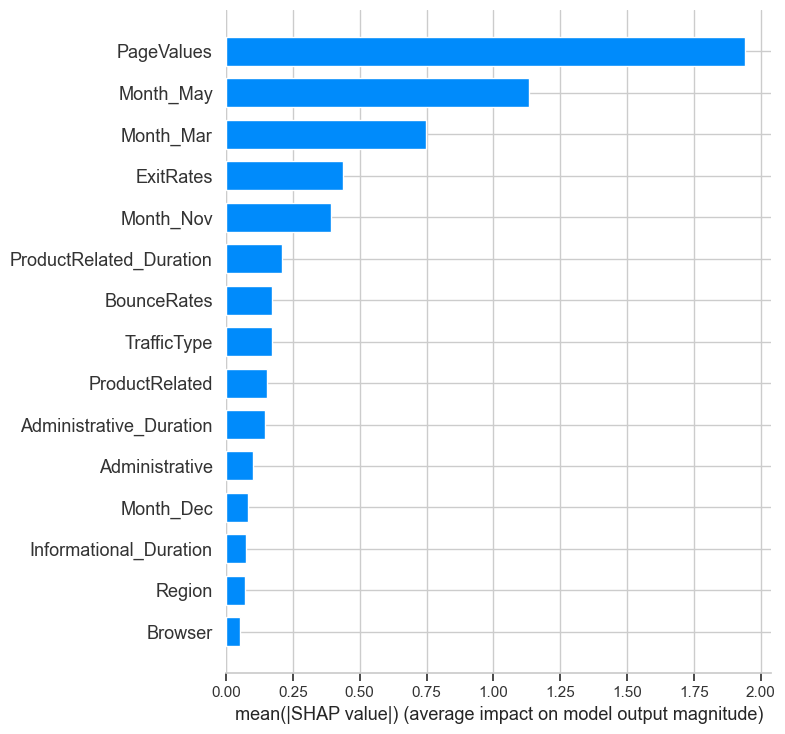

In [87]:
# Global SHAP – Bar Summary Plot (Top Features)
shap.summary_plot(
    shap_values_pos,
    X_train_df,
    plot_type="bar",
    max_display=15,
    show=True
)


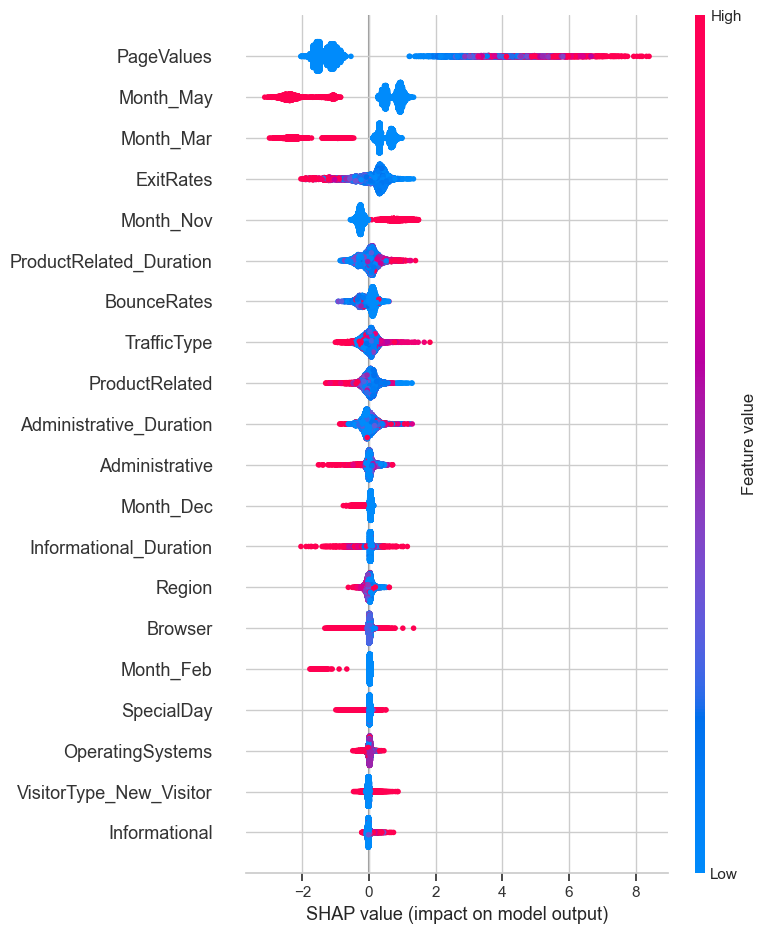

In [88]:
# Global SHAP – Beeswarm Plot (Detailed)
shap.summary_plot(
    shap_values_pos,
    X_train_df,
    max_display=20,
    show=True
)


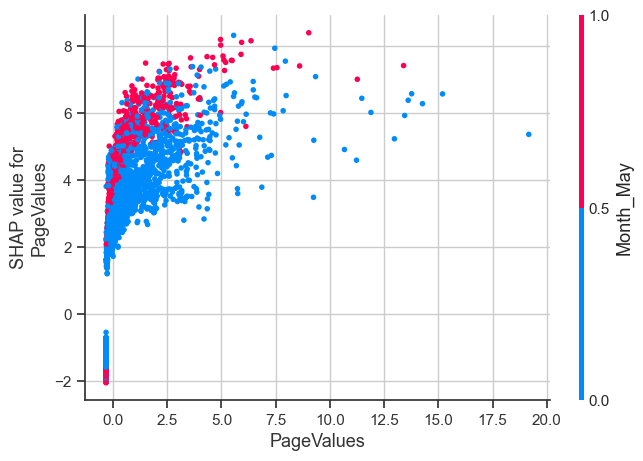

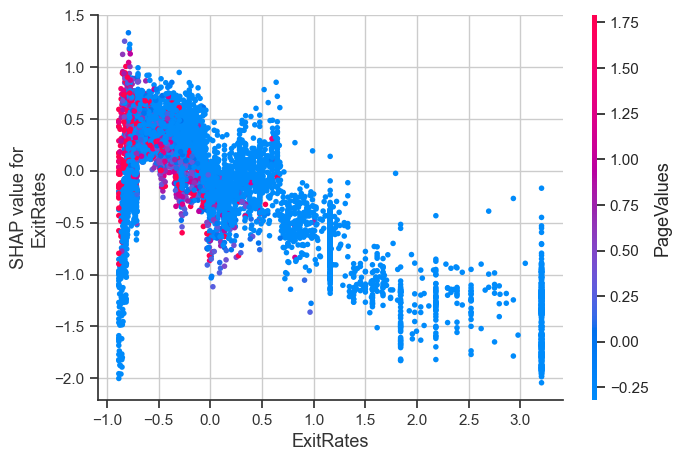

In [89]:
# SHAP Dependence Plots (Per-Feature Behavior)
shap.dependence_plot(
    "PageValues",
    shap_values_pos,
    X_train_df,
    show=True
)

shap.dependence_plot(
    "ExitRates",
    shap_values_pos,
    X_train_df,
    show=True
)


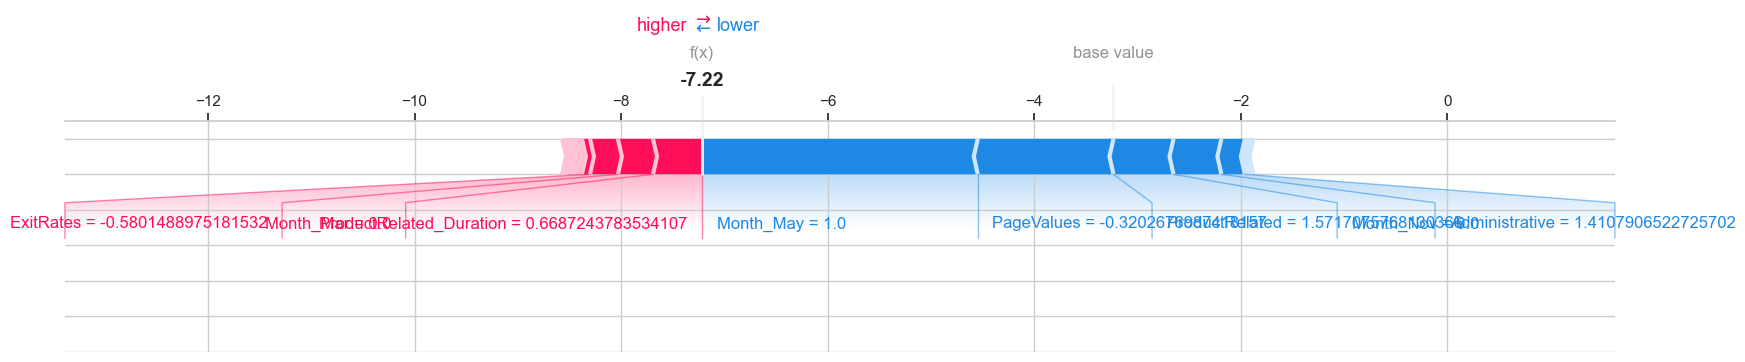

In [90]:
# Local Explanation – Single Session (Force Plot)
i = 100

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_values_pos[i],
    X_train_df.iloc[i],
    matplotlib=True
)


In [91]:
#  Save Plots for Report / Slides
import matplotlib.pyplot as plt

# Example: after a summary_plot, run:
plt.savefig("shap_summary_bar.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [92]:
fig = plt.gcf()
fig.savefig("shap_summary_beeswarm.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# SHAP Stability Analysis

In [94]:
# ==============================
# SHAP Stability Analysis
# ==============================

from lightgbm import LGBMClassifier
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure these already exist from your earlier steps:
# X_train_df      -> preprocessed training data (DataFrame)
# feature_names   -> list of feature names
# y_train_reset   -> y_train.reset_index(drop=True)

# 1. Subsample for SHAP (for speed)
sample_size = min(2000, len(X_train_df))

rng = np.random.RandomState(42)
idx = rng.choice(len(X_train_df), size=sample_size, replace=False)

X_shap = X_train_df.iloc[idx]
y_shap = y_train_reset.iloc[idx]

# 2. Define seeds and storage
seeds = [0, 1, 2, 3, 4]    # you can change or extend this
global_importances = {}    # will store mean |SHAP| per run
top_k = 10                 # top K features to compare for overlap

# 3. Train multiple LGBM models and compute global SHAP importance
for seed in seeds:
    print(f"Training LightGBM with random_state={seed}...")

    lgb_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )

    lgb_model.fit(X_shap, y_shap)

    # SHAP explainer and values
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_shap)

    # Handle binary classification (list vs array)
    if isinstance(shap_vals, list):
        shap_vals_pos = shap_vals[1]   # class 1 (purchase)
    else:
        shap_vals_pos = shap_vals

    # Global importance = mean |SHAP| per feature
    mean_abs_shap = np.abs(shap_vals_pos).mean(axis=0)

    global_importances[seed] = pd.Series(
        mean_abs_shap,
        index=feature_names
    ).sort_values(ascending=False)

print("\nFinished computing global SHAP importances for all seeds.")


Training LightGBM with random_state=0...
[LightGBM] [Info] Number of positive: 304, number of negative: 1696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Training LightGBM with random_state=1...
[LightGBM] [Info] Number of positive: 304, number of negative: 1696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Training LightGBM with random_state=2...
[LightGBM] [Info] Number of positive: 304, number of negative: 1696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Training LightGBM with random_state=3...
[LightGBM] [Info] Number of positive: 304, number of negative: 1696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Training LightGBM with random_state=4...
[LightGBM] [Info] Number of positive: 304, number of negative: 1696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Finished computing global SHAP importances for all seeds.


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Spearman correlation of global SHAP rankings across seeds:
          0         1         2         3         4
0  1.000000  0.981769  0.985218  0.970436  0.970929
1  0.981769  1.000000  0.983740  0.989160  0.979798
2  0.985218  0.983740  1.000000  0.984233  0.980783
3  0.970436  0.989160  0.984233  1.000000  0.980783
4  0.970929  0.979798  0.980783  0.980783  1.000000


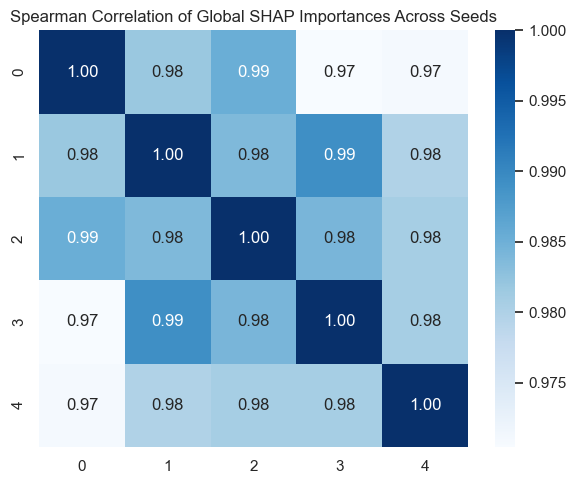

In [95]:
# Spearman Correlation of Global Importances
# Combine all global importances into one DataFrame
gi_df = pd.DataFrame(global_importances)

# Spearman correlation between runs
spearman_corr = gi_df.corr(method='spearman')
print("\nSpearman correlation of global SHAP rankings across seeds:")
print(spearman_corr)

# Optional: heatmap visualization
plt.figure(figsize=(6,5))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Spearman Correlation of Global SHAP Importances Across Seeds")
plt.tight_layout()
plt.show()


In [96]:
# Top-K Feature Overlap (Jaccard Similarity)
# Compare top-K feature sets between base seed and others
base_seed = seeds[0]
base_topk = set(global_importances[base_seed].head(top_k).index)

jaccard_scores = {}

for seed in seeds[1:]:
    this_topk = set(global_importances[seed].head(top_k).index)
    intersection = len(base_topk & this_topk)
    union = len(base_topk | this_topk)
    jaccard = intersection / union if union > 0 else 0.0
    jaccard_scores[seed] = jaccard

print(f"\nTop-{top_k} feature overlap (Jaccard) vs seed {base_seed}:")
for seed, score in jaccard_scores.items():
    print(f"Seed {seed}: Jaccard = {score:.3f}")



Top-10 feature overlap (Jaccard) vs seed 0:
Seed 1: Jaccard = 1.000
Seed 2: Jaccard = 1.000
Seed 3: Jaccard = 1.000
Seed 4: Jaccard = 1.000
